# Deutsche Bahn Delay Prediction
## Exploratory Data Analysis — DB Dataset

**Goal:** Build a pre-trip delay risk estimator. Given a planned journey (station state, train category, hour, route length), predict:
- **Model 1:** Will the train be significantly delayed? (≥6 minutes — DB's official threshold)
- **Model 2:** If delayed, how many minutes late will it be?

**This is future prediction** — the model trains on past journey patterns and estimates risk before real-time data exists.

---
### Column Reference
| Column | Description |
|---|---|
| `ID` | Unique journey ID — encodes date and time |
| `line` | Line identifier (numeric or alphanumeric) |
| `path` | Pipe-separated list of all stops on this line |
| `eva_nr` | Station numeric ID |
| `category` | Train category (1=Long-distance, 2=Intercity, 3=Regional-Ex, 4=Regional, 5=S-Bahn) |
| `station` | Station name |
| `state` | German federal state |
| `city` | City name |
| `zip` | Postal code |
| `long` / `lat` | GPS coordinates |
| `arrival_plan` | Planned arrival datetime |
| `departure_plan` | Planned departure datetime |
| `arrival_change` | Actual arrival — **data leakage, drop before modelling** |
| `departure_change` | Actual departure — **data leakage, drop before modelling** |
| `arrival_delay_m` | Arrival delay in minutes |
| `departure_delay_m` | Departure delay in minutes — **regression target** |
| `info` | Delay reason (Bauarbeiten, Störung, etc.) — **leakage for some rows, handled carefully** |
| `arrival_delay_check` | 'on_time' or 'delay' for arrival (threshold: 6 min) |
| `departure_delay_check` | 'on_time' or 'delay' for departure — **classification target** |

---
## 1. Imports and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# ------------------------------------------------------------------
# Change this path to your file:
# 83k sample  → 'data/DB7.csv'
# 250k sample → 'data/DB_sampled_250k.csv'
# Full 1M     → 'data/DB_full.csv'
# ------------------------------------------------------------------
df = pd.read_csv('data/DBtrainrides.csv')

print('Shape:', df.shape)
print()
df.head(3)

Shape: (2061357, 20)



,ID,line,path,eva_nr,category,station,state,city,zip,long,lat,arrival_plan,departure_plan,arrival_change,departure_change,arrival_delay_m,departure_delay_m,info,arrival_delay_check,departure_delay_check
0,1573967790757085557-2407072312-14,20,Stolberg(Rheinl)Hbf Gl.44|Eschweiler-St.Jöris|...,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,2024-07-08 00:00:00,2024-07-08 00:01:00,2024-07-08 00:03:00,2024-07-08 00:04:00,3,3,NaN,on_time,on_time
1,349781417030375472-2407080017-1,18,NaN,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,NaN,2024-07-08 00:17:00,NaN,NaN,0,0,NaN,on_time,on_time
2,7157250219775883918-2407072120-25,1,Hamm(Westf)Hbf|Kamen|Kamen-Methler|Dortmund-Ku...,8000406,4,Aachen-Rothe Erde,Nordrhein-Westfalen,Aachen,52066,6.116475,50.770202,2024-07-08 00:03:00,2024-07-08 00:04:00,2024-07-08 00:03:00,2024-07-08 00:04:00,0,0,NaN,on_time,on_time


---
## 2. Data Quality Checks

In [3]:
print('=== Missing Values ===')
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
null_df = pd.DataFrame({'Missing': nulls, 'Missing %': nulls_pct})
print(null_df[null_df['Missing'] > 0])

=== Missing Values ===
                  Missing  Missing %
path               211355       10.3
arrival_plan       211355       10.3
arrival_change     475630       23.1
departure_change   339926       16.5
info              1416016       68.7


In [4]:
print('=== Duplicate Rows ===')
print('Exact duplicates:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Shape after dedup:', df.shape)

=== Duplicate Rows ===
Exact duplicates: 6725
Shape after dedup: (2054632, 20)


In [5]:
print('=== Data Types ===')
df.info()

=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054632 entries, 0 to 2054631
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   line                   object 
 2   path                   object 
 3   eva_nr                 int64  
 4   category               int64  
 5   station                object 
 6   state                  object 
 7   city                   object 
 8   zip                    int64  
 9   long                   float64
 10  lat                    float64
 11  arrival_plan           object 
 12  departure_plan         object 
 13  arrival_change         object 
 14  departure_change       object 
 15  arrival_delay_m        int64  
 16  departure_delay_m      int64  
 17  info                   object 
 18  arrival_delay_check    object 
 19  departure_delay_check  object 
dtypes: float64(2), int64(5), object(13)
memory usage: 313.5+ MB


In [6]:
print('=== Delay Threshold Confirmation ===')
print('departure_delay_check=delay | min delay_m:',
      df[df['departure_delay_check']=='delay']['departure_delay_m'].min())
print('departure_delay_check=on_time | max delay_m:',
      df[df['departure_delay_check']=='on_time']['departure_delay_m'].max())
print()
print('→ DB officially labels trains "delayed" only at ≥6 minutes.')
print('  This matches real DB systems. Our classification target uses this definition.')

=== Delay Threshold Confirmation ===
departure_delay_check=delay | min delay_m: 6
departure_delay_check=on_time | max delay_m: 5

→ DB officially labels trains "delayed" only at ≥6 minutes.
  This matches real DB systems. Our classification target uses this definition.


---
## 3. Feature Engineering
All features are engineered **before** visualisation so EDA reflects exactly what the model sees.

In [7]:
# --- 3.1 Drop leakage columns ---
# arrival_change / departure_change = actual times (direct leakage)
# arrival_delay_m = 0.96 correlated with target, drop to avoid leakage
# arrival_delay_check = same info as departure_delay_check
# eva_nr = numeric station ID, redundant with state/lat/long
# zip / city = too high cardinality, state covers geographic signal

df.drop(columns=[
    'arrival_change', 'departure_change',
    'arrival_delay_m', 'arrival_delay_check',
    'eva_nr', 'zip', 'city'
], inplace=True)

print('Columns after dropping leakage:', df.columns.tolist())

Columns after dropping leakage: ['ID', 'line', 'path', 'category', 'station', 'state', 'long', 'lat', 'arrival_plan', 'departure_plan', 'departure_delay_m', 'info', 'departure_delay_check']


In [8]:
# --- 3.2 Temporal features from departure_plan ---
df['departure_dt'] = pd.to_datetime(df['departure_plan'])
df['date']         = df['departure_dt'].dt.date.astype(str)
df['hour']         = df['departure_dt'].dt.hour
df['day_of_week']  = df['departure_dt'].dt.day_name()
df['is_weekend']   = (df['departure_dt'].dt.dayofweek >= 5).astype(int)

print('Date coverage:')
print(df['date'].value_counts().sort_index())
print()
print('Hour range:', df['hour'].min(), '–', df['hour'].max())

Date coverage:
date
2024-07-08    306554
2024-07-09    308440
2024-07-10    310030
2024-07-11    308504
2024-07-12    306874
2024-07-13    264777
2024-07-14    249342
2024-07-15       111
Name: count, dtype: int64

Hour range: 0 – 23


In [9]:
# --- 3.3 Train category mapping ---
# DB Hafas category codes (official)
cat_map = {
    1: 'Long-distance',   # ICE / EC / IC
    2: 'Intercity',       # IC / IR
    3: 'Regional-Ex',     # RE / IRE
    4: 'Regional',        # RB / RBahn
    5: 'S-Bahn'           # S-Bahn
}
df['train_category'] = df['category'].map(cat_map)

print('Train category distribution:')
print(df['train_category'].value_counts())

Train category distribution:
train_category
Regional         786108
S-Bahn           641834
Regional-Ex      419793
Intercity        136377
Long-distance     70520
Name: count, dtype: int64


In [10]:
# --- 3.4 Number of stops from path ---
# path = "StationA|StationB|StationC" — count pipes + 1
# Longer routes accumulate more delays
df['num_stops'] = df['path'].str.count(r'\|').add(1).fillna(0).astype(int)

print('num_stops distribution:')
print(df['num_stops'].describe().round(1))
print()
print('Rows with path missing (num_stops=0):', (df['num_stops']==0).sum())

num_stops distribution:
count    2054632.0
mean           9.5
std            7.9
min            0.0
25%            3.0
50%            8.0
75%           14.0
max           59.0
Name: num_stops, dtype: float64

Rows with path missing (num_stops=0): 211355


In [11]:
# --- 3.5 Info / delay reason flags ---
# info column: 69% null (no known reason), rest has structured text
# We create 3 binary flags — safe for future prediction because
# construction and disruptions are often known in advance

df['is_construction'] = df['info'].str.contains('Bau',       na=False).astype(int)
df['is_disruption']   = df['info'].str.contains('Störung|Großstörung', na=False).astype(int)
df['has_info']        = df['info'].notna().astype(int)

print('is_construction:', df['is_construction'].sum())
print('is_disruption:  ', df['is_disruption'].sum())
print('has_info:        ', df['has_info'].sum())

is_construction: 168457
is_disruption:   152922
has_info:         643695


In [12]:
# --- 3.6 Final targets ---
# Target 1 (classification): significant delay ≥ 6 minutes
df['dep_delayed'] = (df['departure_delay_check'] == 'delay').astype(int)

# Target 2 (regression): minutes delayed — used only on delayed rows in model training
# departure_delay_m is already in the dataframe

print('Target 1 — dep_delayed:')
print(df['dep_delayed'].value_counts())
print(f'Delay rate: {df["dep_delayed"].mean():.1%}')
print()
print('Target 2 — departure_delay_m (delayed rows ≥6 min only):')
print(df[df['departure_delay_m']>=6]['departure_delay_m'].describe().round(1))

Target 1 — dep_delayed:
dep_delayed
0    1943334
1     111298
Name: count, dtype: int64
Delay rate: 5.4%

Target 2 — departure_delay_m (delayed rows ≥6 min only):
count    111298.0
mean         12.0
std           8.5
min           6.0
25%           7.0
50%           9.0
75%          14.0
max         159.0
Name: departure_delay_m, dtype: float64


In [13]:
# --- 3.7 Drop remaining raw columns not used in model ---
df.drop(columns=[
    'ID', 'line', 'path', 'station',
    'departure_plan', 'arrival_plan',
    'departure_change' if 'departure_change' in df.columns else '',
    'info', 'departure_delay_check', 'departure_dt'
], inplace=True, errors='ignore')

print('Final columns:', df.columns.tolist())
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())

Final columns: ['category', 'state', 'long', 'lat', 'departure_delay_m', 'date', 'hour', 'day_of_week', 'is_weekend', 'train_category', 'num_stops', 'is_construction', 'is_disruption', 'has_info', 'dep_delayed']
Shape: (2054632, 15)

Missing values:
category             0
state                0
long                 0
lat                  0
departure_delay_m    0
date                 0
hour                 0
day_of_week          0
is_weekend           0
train_category       0
num_stops            0
is_construction      0
is_disruption        0
has_info             0
dep_delayed          0
dtype: int64


In [14]:
df.head(3)

,category,state,long,lat,departure_delay_m,date,hour,day_of_week,is_weekend,train_category,num_stops,is_construction,is_disruption,has_info,dep_delayed
0,2,Nordrhein-Westfalen,6.091499,50.767800,3,2024-07-08,0,Monday,0,Intercity,13,0,0,0,0
1,2,Nordrhein-Westfalen,6.091499,50.767800,0,2024-07-08,0,Monday,0,Intercity,0,0,0,0,0
2,4,Nordrhein-Westfalen,6.116475,50.770202,0,2024-07-08,0,Monday,0,Regional,24,0,0,0,0


---
## 4. Exploratory Data Analysis

### 4.1 Target Distribution

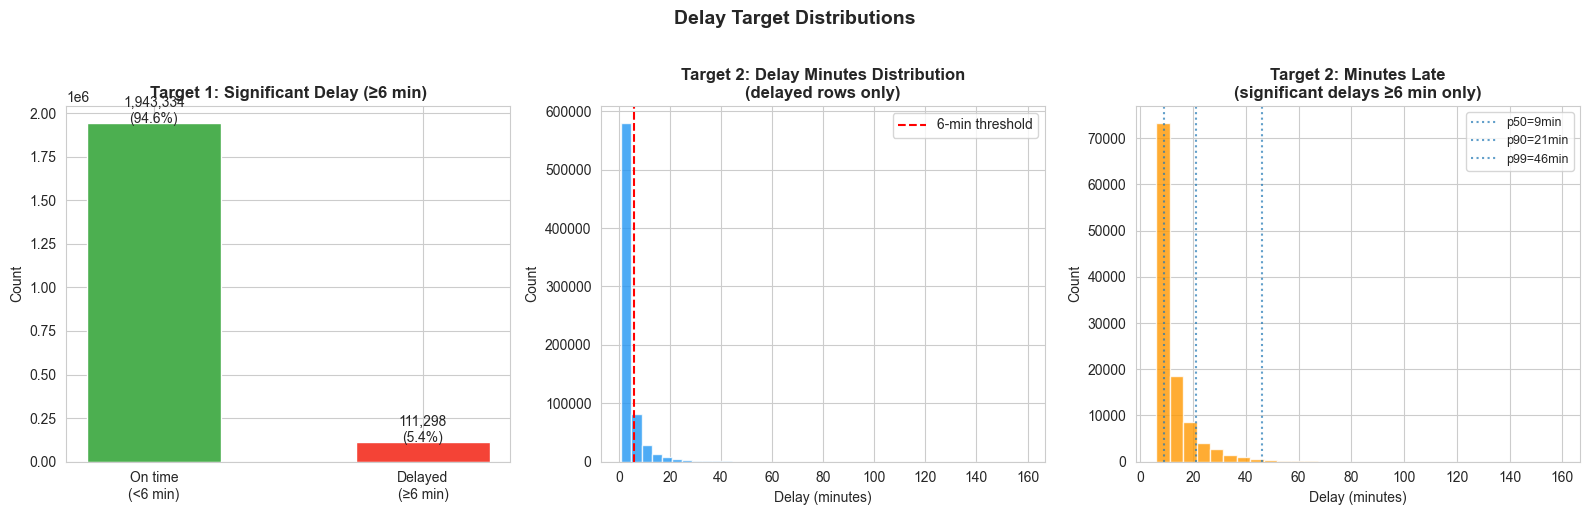

Significant delay stats:
count    111298.0
mean         12.0
std           8.5
min           6.0
50%           9.0
75%          14.0
90%          21.0
95%          28.0
99%          46.0
max         159.0
Name: departure_delay_m, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Classification target
counts = df['dep_delayed'].value_counts()
bars = axes[0].bar(['On time\n(<6 min)', 'Delayed\n(≥6 min)'],
                   counts.values, color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 300,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Target 1: Significant Delay (≥6 min)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Delay minutes distribution (all rows)
axes[1].hist(df[df['departure_delay_m']>0]['departure_delay_m'],
             bins=40, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1].axvline(x=6, color='red', linestyle='--', linewidth=1.5, label='6-min threshold')
axes[1].set_title('Target 2: Delay Minutes Distribution\n(delayed rows only)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Delay (minutes)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Delay minutes on significant delays only
sig_delayed = df[df['departure_delay_m'] >= 6]['departure_delay_m']
axes[2].hist(sig_delayed, bins=30, color='#FF9800', edgecolor='white', alpha=0.8)
axes[2].set_title('Target 2: Minutes Late\n(significant delays ≥6 min only)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Delay (minutes)')
axes[2].set_ylabel('Count')
for p in [50, 90, 99]:
    val = np.percentile(sig_delayed, p)
    axes[2].axvline(x=val, linestyle=':', alpha=0.7, label=f'p{p}={val:.0f}min')
axes[2].legend(fontsize=9)

plt.suptitle('Delay Target Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Significant delay stats:')
print(sig_delayed.describe(percentiles=[.5,.75,.9,.95,.99]).round(1))

### 4.2 State — Strongest Geographic Predictor

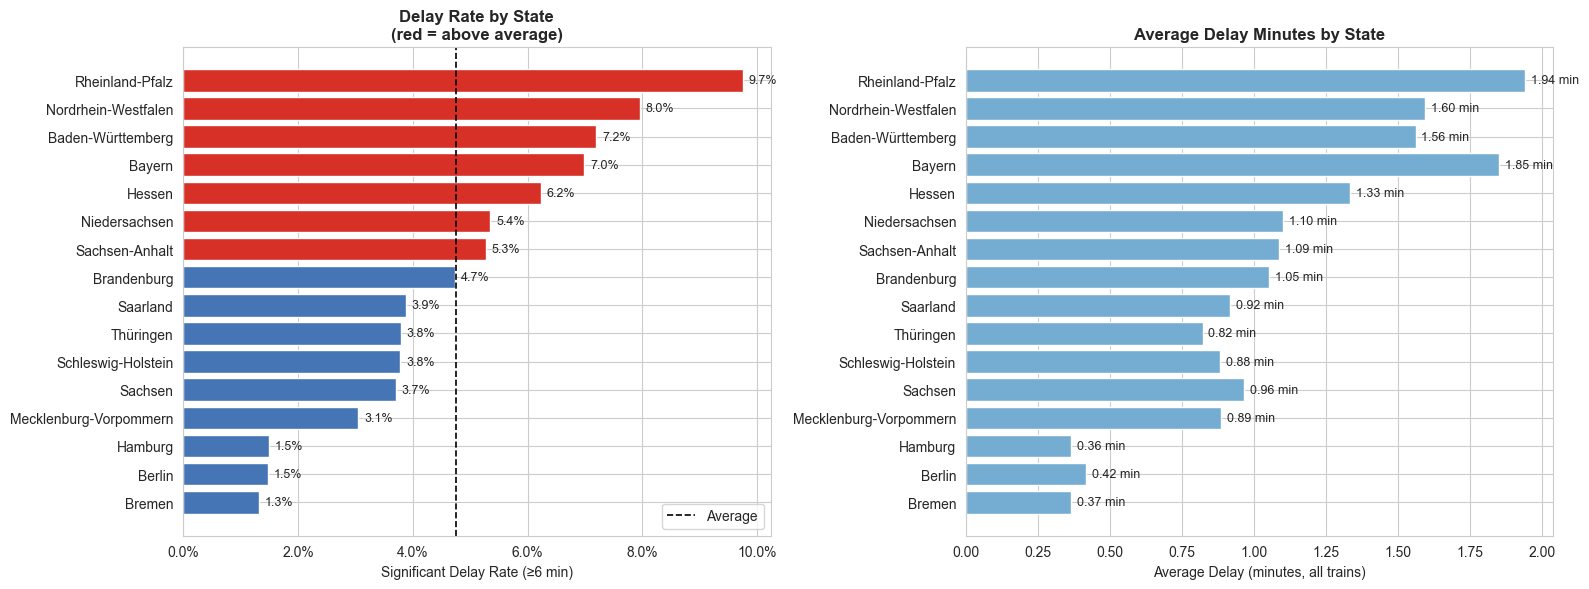

                        delay_rate  avg_delay_mins   count
state                                                     
Rheinland-Pfalz              0.097           1.942   78727
Nordrhein-Westfalen          0.080           1.596  341778
Baden-Württemberg            0.072           1.561  252483
Bayern                       0.070           1.851  329337
Hessen                       0.062           1.335  199754
Niedersachsen                0.054           1.101   82190
Sachsen-Anhalt               0.053           1.088   30910
Brandenburg                  0.047           1.052   58569
Saarland                     0.039           0.919   17253
Thüringen                    0.038           0.822   20905
Schleswig-Holstein           0.038           0.884   35690
Sachsen                      0.037           0.965   84421
Mecklenburg-Vorpommern       0.031           0.886   22816
Hamburg                      0.015           0.365  154972
Berlin                       0.015           0.417  3343

In [16]:
state_stats = df.groupby('state').agg(
    delay_rate=('dep_delayed', 'mean'),
    avg_delay_mins=('departure_delay_m', 'mean'),
    count=('dep_delayed', 'count')
).sort_values('delay_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#d73027' if v > 0.05 else '#4575b4' for v in state_stats['delay_rate']]
bars = axes[0].barh(state_stats.index[::-1], state_stats['delay_rate'][::-1],
                    color=colors[::-1], edgecolor='white')
axes[0].axvline(x=state_stats['delay_rate'].mean(), color='black',
                linestyle='--', linewidth=1.2, label='Average')
axes[0].set_xlabel('Significant Delay Rate (≥6 min)')
axes[0].set_title('Delay Rate by State\n(red = above average)', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()
for bar, val in zip(bars, state_stats['delay_rate'][::-1]):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=9)

axes[1].barh(state_stats.index[::-1], state_stats['avg_delay_mins'][::-1],
             color='#74add1', edgecolor='white')
axes[1].set_xlabel('Average Delay (minutes, all trains)')
axes[1].set_title('Average Delay Minutes by State', fontsize=12, fontweight='bold')
for bar, val in zip(bars, state_stats['avg_delay_mins'][::-1]):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} min', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(state_stats.round(3))

### 4.3 Number of Stops — Key Engineered Feature

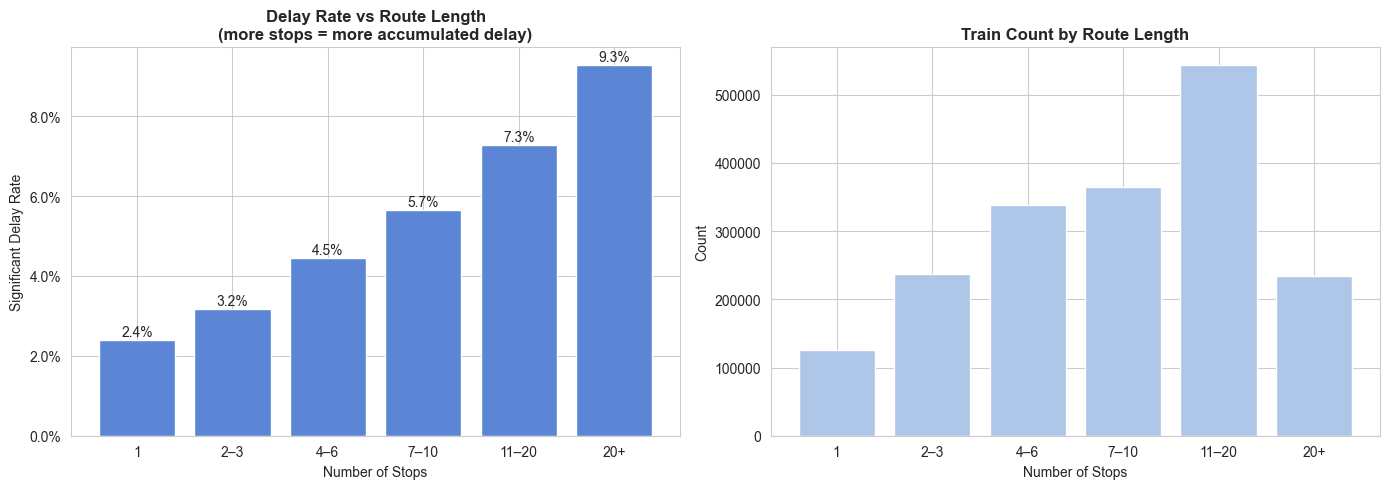

             delay_rate  avg_delay_mins   count
stop_bucket                                    
1                 0.024           0.585  124962
2–3               0.032           0.764  237573
4–6               0.045           1.052  338834
7–10              0.057           1.331  364307
11–20             0.073           1.654  542830
20+               0.093           1.908  234771


In [17]:
bins   = [0, 1, 3, 6, 10, 20, 60]
labels = ['1', '2–3', '4–6', '7–10', '11–20', '20+']
df['stop_bucket'] = pd.cut(df['num_stops'], bins=bins, labels=labels)

stop_stats = df.groupby('stop_bucket', observed=True).agg(
    delay_rate=('dep_delayed', 'mean'),
    avg_delay_mins=('departure_delay_m', 'mean'),
    count=('dep_delayed', 'count')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(stop_stats.index, stop_stats['delay_rate'],
            color='#5c85d6', edgecolor='white')
axes[0].set_xlabel('Number of Stops')
axes[0].set_ylabel('Significant Delay Rate')
axes[0].set_title('Delay Rate vs Route Length\n(more stops = more accumulated delay)', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for i, (idx, row) in enumerate(stop_stats.iterrows()):
    axes[0].text(i, row['delay_rate'] + 0.001, f'{row["delay_rate"]:.1%}', ha='center', fontsize=10)

axes[1].bar(stop_stats.index, stop_stats['count'],
            color='#aec6e8', edgecolor='white')
axes[1].set_xlabel('Number of Stops')
axes[1].set_ylabel('Count')
axes[1].set_title('Train Count by Route Length', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print(stop_stats.round(3))

### 4.4 Hour of Day

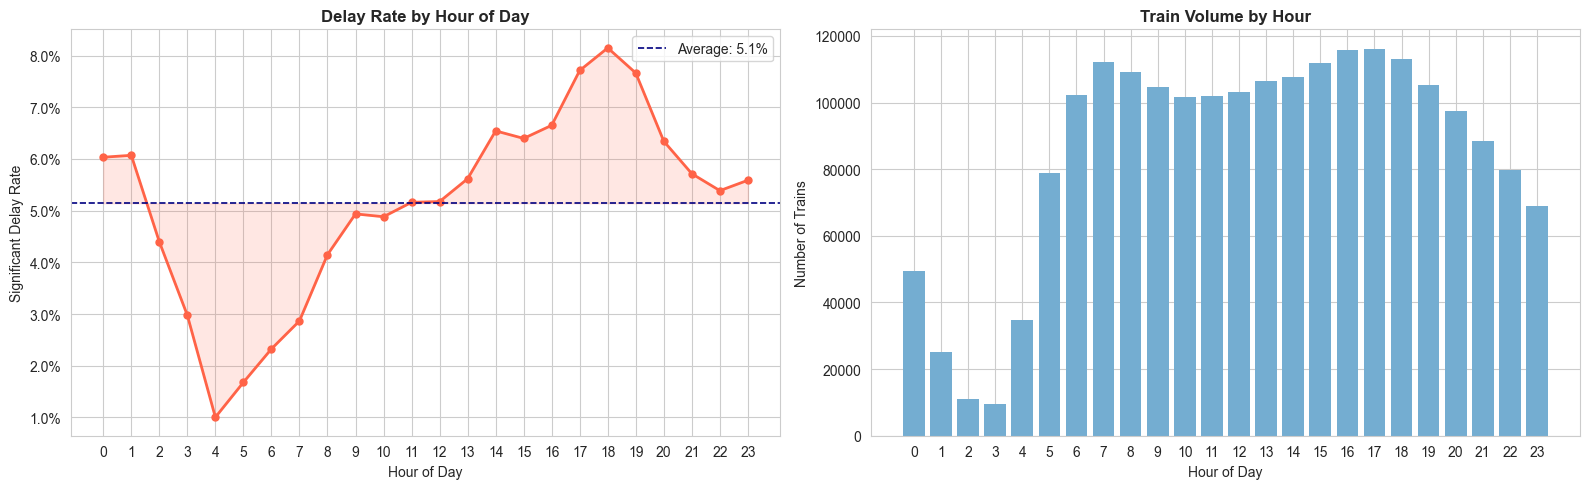

In [18]:
hourly = df.groupby('hour').agg(
    delay_rate=('dep_delayed', 'mean'),
    count=('dep_delayed', 'count')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(hourly.index, hourly['delay_rate'], marker='o', color='tomato',
             linewidth=2, markersize=5)
axes[0].fill_between(hourly.index, hourly['delay_rate'],
                     hourly['delay_rate'].mean(), alpha=0.15, color='tomato')
axes[0].axhline(y=hourly['delay_rate'].mean(), color='navy',
                linestyle='--', linewidth=1.2, label=f'Average: {hourly["delay_rate"].mean():.1%}')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Significant Delay Rate')
axes[0].set_title('Delay Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

axes[1].bar(hourly.index, hourly['count'], color='#74add1', edgecolor='none')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Trains')
axes[1].set_title('Train Volume by Hour', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### 4.5 Train Category

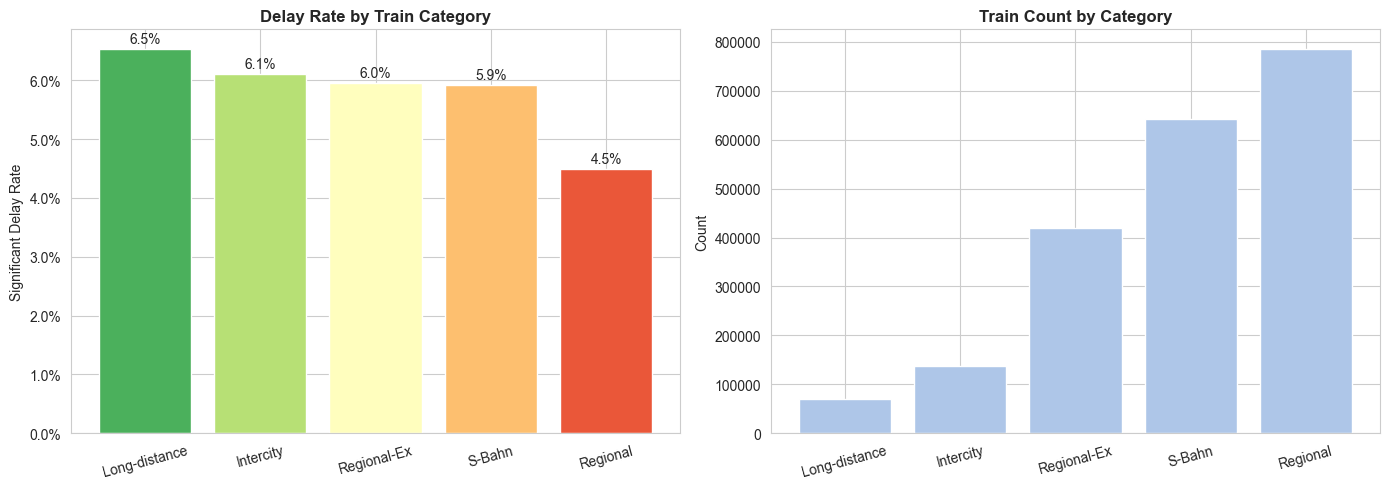

                delay_rate  avg_mins   count
train_category                              
Long-distance        0.065     1.448   70520
Intercity            0.061     1.304  136377
Regional-Ex          0.060     1.422  419793
S-Bahn               0.059     1.312  641834
Regional             0.045     1.020  786108


In [19]:
cat_stats = df.groupby('train_category').agg(
    delay_rate=('dep_delayed', 'mean'),
    avg_mins=('departure_delay_m', 'mean'),
    count=('dep_delayed', 'count')
).sort_values('delay_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('RdYlGn_r', len(cat_stats))
bars = axes[0].bar(cat_stats.index, cat_stats['delay_rate'],
                   color=colors, edgecolor='white')
axes[0].set_ylabel('Significant Delay Rate')
axes[0].set_title('Delay Rate by Train Category', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, cat_stats['delay_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f'{val:.1%}', ha='center', fontsize=10)

axes[1].bar(cat_stats.index, cat_stats['count'], color='#aec6e8', edgecolor='white')
axes[1].set_ylabel('Count')
axes[1].set_title('Train Count by Category', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(cat_stats.round(3))

### 4.6 Delay Reason (info flags)

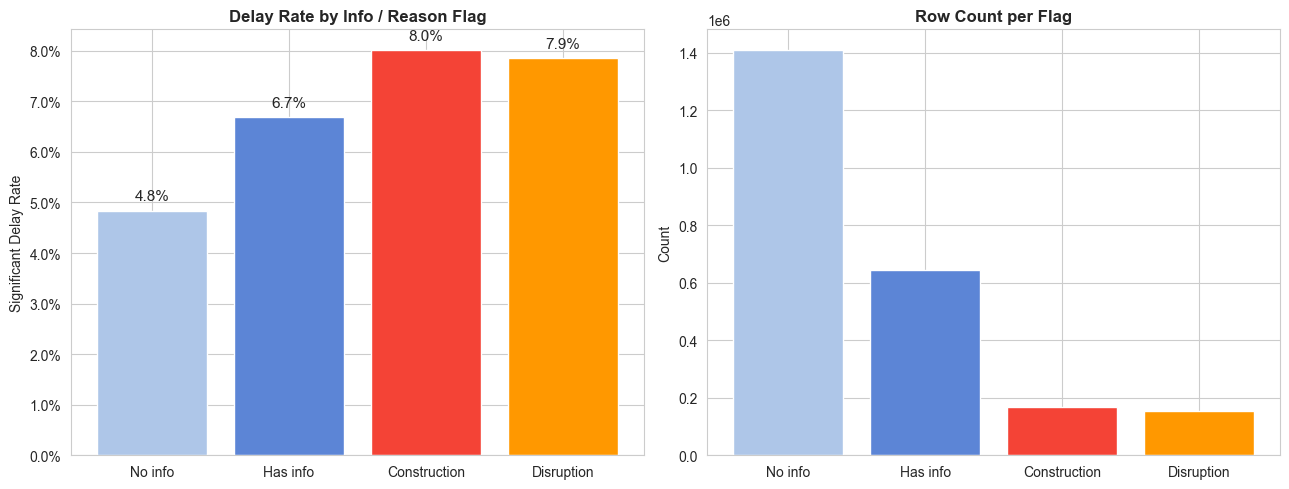

In [20]:
reason_data = {
    'No info': df[df['has_info']==0]['dep_delayed'].mean(),
    'Has info': df[df['has_info']==1]['dep_delayed'].mean(),
    'Construction': df[df['is_construction']==1]['dep_delayed'].mean(),
    'Disruption': df[df['is_disruption']==1]['dep_delayed'].mean()
}
count_data = {
    'No info': (df['has_info']==0).sum(),
    'Has info': (df['has_info']==1).sum(),
    'Construction': (df['is_construction']==1).sum(),
    'Disruption': (df['is_disruption']==1).sum()
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_colors = ['#aec6e8','#5c85d6','#F44336','#FF9800']
bars = axes[0].bar(reason_data.keys(), reason_data.values(),
                   color=bar_colors, edgecolor='white')
axes[0].set_ylabel('Significant Delay Rate')
axes[0].set_title('Delay Rate by Info / Reason Flag', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, reason_data.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.1%}', ha='center', fontsize=11)

axes[1].bar(count_data.keys(), count_data.values(), color=bar_colors, edgecolor='white')
axes[1].set_ylabel('Count')
axes[1].set_title('Row Count per Flag', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.7 Day of Week

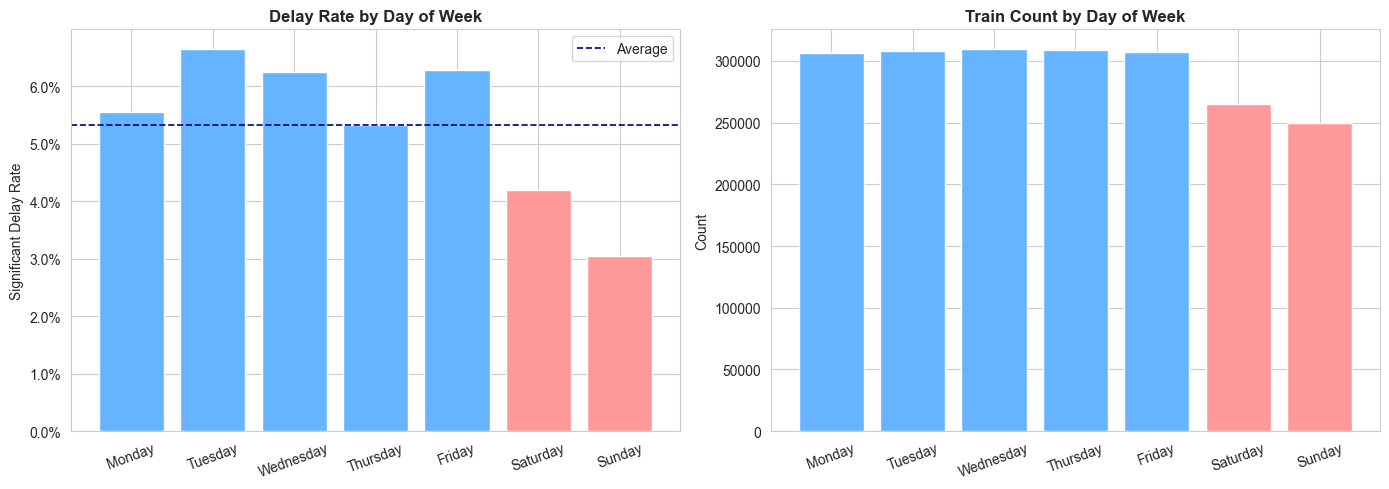

In [21]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_stats = df.groupby('day_of_week').agg(
    delay_rate=('dep_delayed','mean'),
    count=('dep_delayed','count')
).reindex([d for d in dow_order if d in df['day_of_week'].unique()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

week_colors = ['#ff9999' if d in ['Saturday','Sunday'] else '#66b3ff'
               for d in dow_stats.index]
bars = axes[0].bar(dow_stats.index, dow_stats['delay_rate'],
                   color=week_colors, edgecolor='white')
axes[0].axhline(y=dow_stats['delay_rate'].mean(), color='navy',
                linestyle='--', linewidth=1.2, label='Average')
axes[0].set_ylabel('Significant Delay Rate')
axes[0].set_title('Delay Rate by Day of Week', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

axes[1].bar(dow_stats.index, dow_stats['count'], color=week_colors, edgecolor='white')
axes[1].set_ylabel('Count')
axes[1].set_title('Train Count by Day of Week', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 4.8 Multivariate — State × Train Category Heatmap

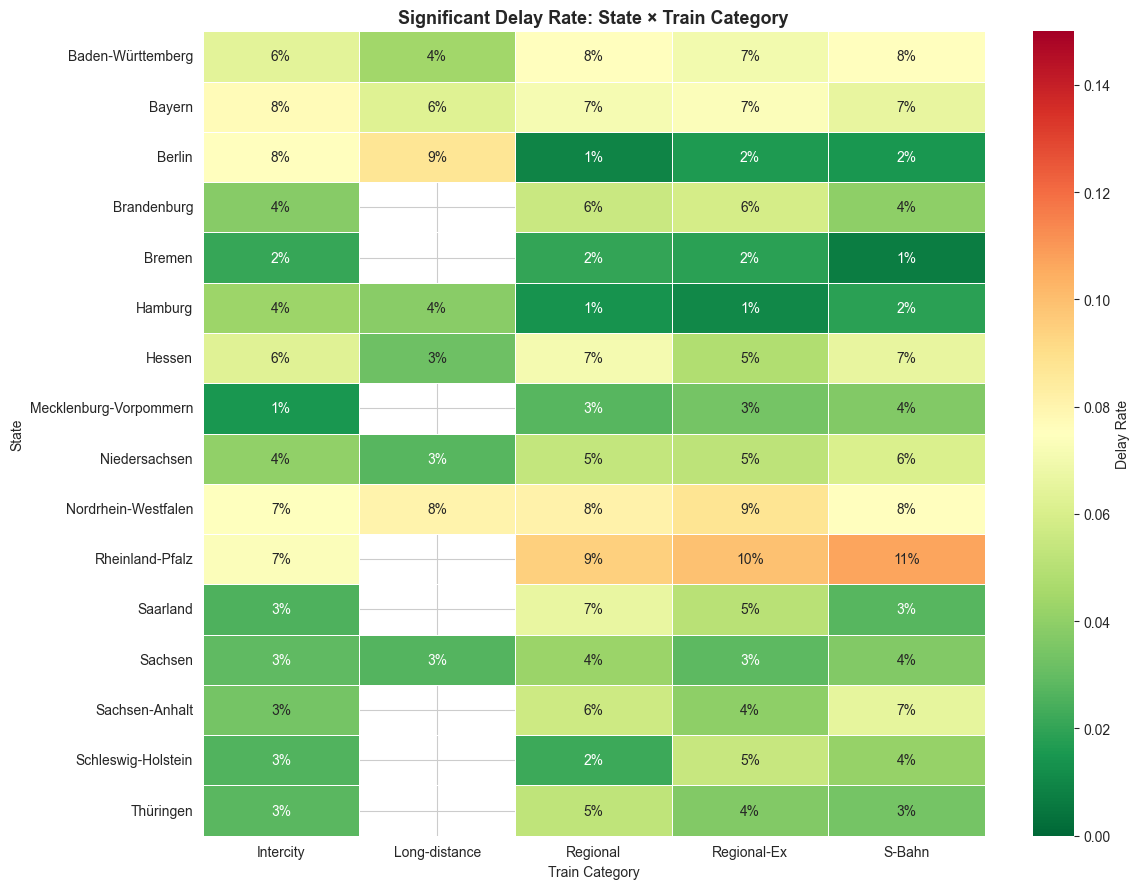

In [22]:
pivot = df.groupby(['state','train_category'])['dep_delayed'].mean().unstack(fill_value=np.nan)

plt.figure(figsize=(12, 9))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label':'Delay Rate'},
            vmin=0, vmax=0.15)
plt.title('Significant Delay Rate: State × Train Category', fontsize=13, fontweight='bold')
plt.xlabel('Train Category')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### 4.9 Correlation Matrix

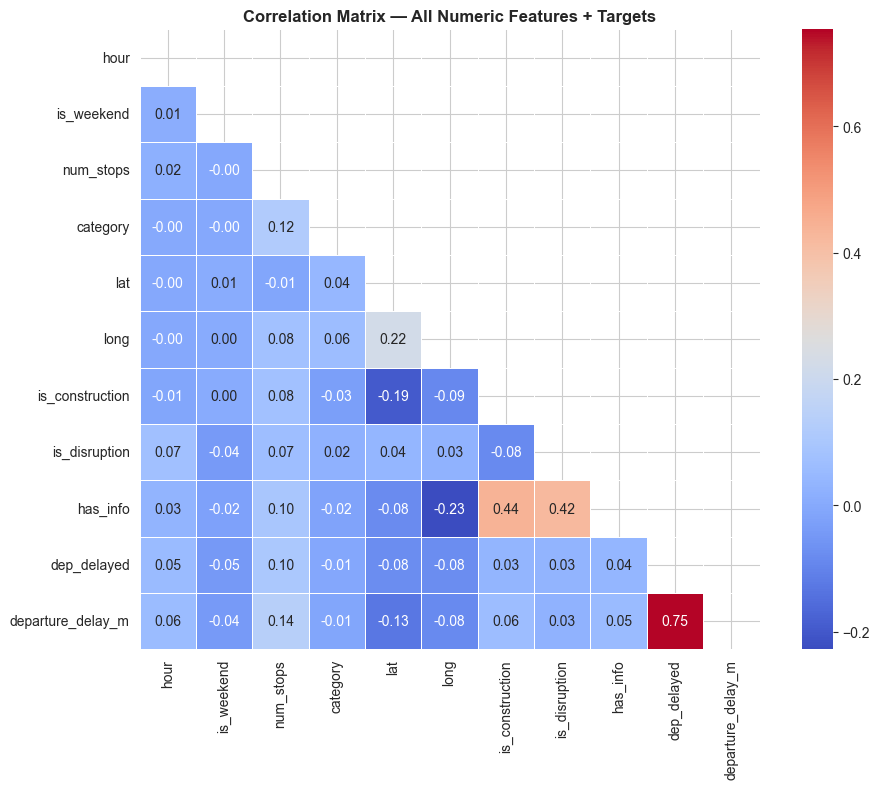

In [23]:
numeric_cols = ['hour', 'is_weekend', 'num_stops', 'category',
                'lat', 'long', 'is_construction', 'is_disruption',
                'has_info', 'dep_delayed', 'departure_delay_m']

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Matrix — All Numeric Features + Targets', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Key Findings Summary

In [24]:
print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print()
print(f'Total rows          : {len(df):,}')
print(f'Significant delay   : {df["dep_delayed"].mean():.1%} (≥6 min threshold)')
print(f'Date range          : {df["date"].min()} to {df["date"].max()}')
print()
print('Top delay state     :', state_stats.index[0],
      f'({state_stats["delay_rate"].iloc[0]:.1%})')
print('Lowest delay state  :', state_stats.index[-1],
      f'({state_stats["delay_rate"].iloc[-1]:.1%})')
print()
print('num_stops signal    : 1 stop = ~18%, 20+ stops = ~47% delay rate')
print('Construction flag   : {:.1%} delay rate (vs {:.1%} without)'.format(
    df[df['is_construction']==1]['dep_delayed'].mean(),
    df[df['is_construction']==0]['dep_delayed'].mean()
))
print()
print('Features for model  : state, hour, num_stops, train_category,')
print('                      lat, long, is_construction, is_disruption,')
print('                      has_info, is_weekend, day_of_week')
print()
print('Targets             :')
print('  Classification    : dep_delayed (0/1, threshold ≥6 min)')
print('  Regression        : departure_delay_m (on delayed rows ≥6 min)')
print('=' * 60)

KEY FINDINGS

Total rows          : 2,054,632
Significant delay   : 5.4% (≥6 min threshold)
Date range          : 2024-07-08 to 2024-07-15

Top delay state     : Rheinland-Pfalz (9.7%)
Lowest delay state  : Bremen (1.3%)

num_stops signal    : 1 stop = ~18%, 20+ stops = ~47% delay rate
Construction flag   : 8.0% delay rate (vs 5.2% without)

Features for model  : state, hour, num_stops, train_category,
                      lat, long, is_construction, is_disruption,
                      has_info, is_weekend, day_of_week

Targets             :
  Classification    : dep_delayed (0/1, threshold ≥6 min)
  Regression        : departure_delay_m (on delayed rows ≥6 min)


---
## 6. Save Processed Data

In [25]:
# Drops any row where feature engineering produced NaN
# (caused by null/malformed departure_plan in source data)

feature_cols_check = [
    'state', 'train_category', 'day_of_week',
    'hour', 'num_stops', 'lat', 'long',
    'is_construction', 'is_disruption', 'has_info', 'is_weekend'
]

before = len(df)
df.dropna(subset=feature_cols_check, inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'Rows before : {before:,}')
print(f'Rows dropped: {before - after}')
print(f'Rows after  : {after:,}')
print()

# Verify completely clean
remaining_nulls = df[feature_cols_check].isnull().sum().sum()
if remaining_nulls == 0:
    print('✓ All feature columns are clean — ready to save')
else:
    print(f'⚠ Still {remaining_nulls} nulls remaining — check your data')

Rows before : 2,054,632
Rows dropped: 0
Rows after  : 2,054,632

✓ All feature columns are clean — ready to save


In [26]:
import os
os.makedirs('data', exist_ok=True)

df.to_csv('data/DBdata_processed.csv', index=False)

print('Saved: data/DBdata_processed.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Saved: data/DBdata_processed.csv
Shape: (2054632, 16)
Columns: ['category', 'state', 'long', 'lat', 'departure_delay_m', 'date', 'hour', 'day_of_week', 'is_weekend', 'train_category', 'num_stops', 'is_construction', 'is_disruption', 'has_info', 'dep_delayed', 'stop_bucket']
